<>:37: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:72: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:72: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:37: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:72: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:72: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/17/jjqjns9j651gvf6nw2ngsn8h0000gn/T/ipykernel_87744/3855815060.

Generating animation. This might take a few seconds...
Successfully saved as 'monte_carlo_pi.gif' in your current directory!


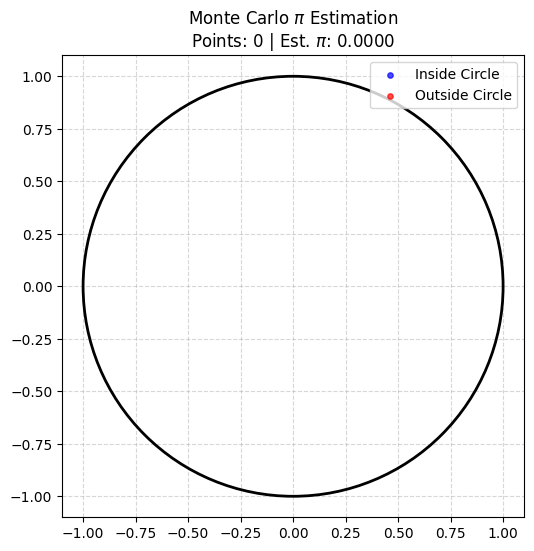

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Configuration ---
num_frames = 100          # Total number of frames in the GIF
points_per_frame = 20     # Number of random points added per frame
gif_filename = "monte_carlo_pi.gif"

# --- Figure Setup ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)

# Draw the unit circle boundary
circle = plt.Circle((0, 0), 1, edgecolor='black', facecolor='none', linewidth=2, zorder=3)
ax.add_patch(circle)

# Initialize empty scatter plots for inside and outside points
scatter_inside = ax.scatter([], [], color='blue', s=15, alpha=0.7, label='Inside Circle')
scatter_outside = ax.scatter([], [], color='red', s=15, alpha=0.7, label='Outside Circle')
ax.legend(loc="upper right")

# Variables to store the cumulative data
x_inside, y_inside = [], []
x_outside, y_outside = [], []
total_inside = 0
total_points = 0

# --- Animation Functions ---
def init():
    """Initializes the empty frame."""
    scatter_inside.set_offsets(np.empty((0, 2)))
    scatter_outside.set_offsets(np.empty((0, 2)))
    ax.set_title("Monte Carlo $\pi$ Estimation\nPoints: 0 | Est. $\pi$: 0.0000")
    return scatter_inside, scatter_outside

def update(frame):
    """Updates the plot for each frame."""
    global total_inside, total_points, x_inside, y_inside, x_outside, y_outside
    
    # Generate random (x, y) coordinates between -1 and 1
    new_x = np.random.uniform(-1, 1, points_per_frame)
    new_y = np.random.uniform(-1, 1, points_per_frame)
    
    # Calculate distance from origin to check if they are inside the unit circle
    distances = new_x**2 + new_y**2
    inside_mask = distances <= 1
    
    # Update running totals
    total_inside += np.sum(inside_mask)
    total_points += points_per_frame
    
    # Append new points to our lists
    x_inside.extend(new_x[inside_mask])
    y_inside.extend(new_y[inside_mask])
    x_outside.extend(new_x[~inside_mask])
    y_outside.extend(new_y[~inside_mask])
    
    # Update the scatter plots with all cumulative points so far
    if len(x_inside) > 0:
        scatter_inside.set_offsets(np.column_stack((x_inside, y_inside)))
    if len(x_outside) > 0:
        scatter_outside.set_offsets(np.column_stack((x_outside, y_outside)))
    
    # Calculate the current estimate of Pi
    pi_estimate = 4 * (total_inside / total_points)
    
    # Update the title dynamically
    ax.set_title(f"Monte Carlo $\pi$ Estimation\nPoints: {total_points} | Est. $\pi$: {pi_estimate:.4f}")
    
    return scatter_inside, scatter_outside

# --- Create and Save the GIF ---
print("Generating animation. This might take a few seconds...")

ani = FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=False)

# Save the animation using PillowWriter
ani.save(gif_filename, writer=PillowWriter(fps=10))

print(f"Successfully saved as '{gif_filename}' in your current directory!")